In [3]:
import json
from pathlib import Path
from typing import Dict, List, Tuple, Optional


def load_evaluation_data(
    eval_type: str,
    base_dir: str,
    model_id: str
) -> List[Tuple[float, float]]:
    """
    Load evaluation data from JSON files in a directory.
    
    Args:
        eval_type: Name of the evaluation type (for error messages)
        base_dir: Base directory path containing the model directory
        model_id: Model identifier (subdirectory name)
    
    Returns:
        List of (degree, perplexity) tuples, sorted by degree
    """
    model_dir = Path(base_dir) / model_id
    
    if not model_dir.exists():
        raise FileNotFoundError(f"Directory not found: {model_dir}")
    
    points = []
    json_files = sorted(model_dir.glob("*.json"))
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            degree = data.get("degree")
            perplexity = data.get("metadata", {}).get("average_perplexity")
            
            if degree is None or perplexity is None:
                print(f"Warning: Missing data in {json_file.name}")
                continue
            
            points.append((degree, perplexity))
        
        except (json.JSONDecodeError, KeyError) as e:
            print(f"Warning: Error reading {json_file.name}: {e}")
            continue
    
    return sorted(points, key=lambda x: x[0])


def load_all_evaluation_data(
    eval_configs: Dict[str, str],
    model_id: str
) -> Dict[str, List[Tuple[float, float]]]:
    """
    Load evaluation data from multiple evaluation types.
    
    Args:
        eval_configs: Dictionary mapping evaluation type names to base directories
        model_id: Model identifier
    
    Returns:
        Dictionary mapping evaluation types to lists of (degree, perplexity) tuples
    """
    data_dict = {}
    
    for eval_type, base_dir in eval_configs.items():
        try:
            points = load_evaluation_data(eval_type, base_dir, model_id)
            data_dict[eval_type] = points
        except FileNotFoundError as e:
            print(f"Error loading {eval_type}: {e}")
            data_dict[eval_type] = []
    
    return data_dict


# Configuration
EVAL_CONFIGS = {
    "Standard": "../eval/basic",
    "Adaptive": "../eval/adaptive",
    "Selective": "../eval/selective",
}

MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

# Load all evaluation data
data_dict = load_all_evaluation_data(EVAL_CONFIGS, MODEL_ID)
data_dict

{'Standard': [(0, 409.42924585250705),
  (30, 39.80174788144919),
  (60, 10.306512481891192),
  (90, 7.666076374741701),
  (120, 6.291075503596892),
  (150, 7.220164457192788),
  (180, 16.684194281697273),
  (210, 855298.2519445557),
  (240, 57624599.0115666),
  (270, 442748494.02296007),
  (300, 24.829794792028572),
  (330, 6.175791849310581),
  (360, 409.3738952118617)],
 'Adaptive': [(0, 409.4040033886066),
  (30, 40.396877515774506),
  (60, 11.567598340603022),
  (90, 3.9200832213346777),
  (120, 6.0207248880313),
  (150, 7.283490550059539),
  (180, 15.644819667706123),
  (210, 849582.3882957422),
  (240, 53817477.18401731),
  (270, 361331573.7568359),
  (300, 1748.4727140046084),
  (330, 5.85853666640245),
  (360, 4.620527281210973)],
 'Selective': [(0, 1.5358154223515437),
  (30, 1.5994751441937227),
  (60, 1.778297176727882),
  (90, 2.098620450267425),
  (120, 2.579159343471894),
  (150, 3.661944412268125),
  (180, 5.123484900364509),
  (210, 3.6966850001078386),
  (240, 2.81348

In [4]:
# Configuration
EVAL_CONFIGS = {
    "Standard": "../eval/basic",
    "Adaptive": "../eval/adaptive",
    "Selective": "../eval/selective",
}

MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"

# Load all evaluation data
llama_3_2_3b_dict = load_all_evaluation_data(EVAL_CONFIGS, MODEL_ID)
llama_3_2_3b_dict

{'Standard': [(0, 1.622319445014),
  (30, 1.35809913621499),
  (60, 1.994506305226913),
  (90, 1.7916286496015696),
  (120, 1.8110109109144945),
  (150, 1.7478156433655665),
  (180, 1.8663202421023295),
  (210, 2.708144497412902),
  (240, 7.619566705364448),
  (270, 11.093398015086468),
  (300, 8660.684172418256),
  (330, 8.11335796232407),
  (360, 1.5226814391521306)],
 'Adaptive': [(0, 1.5532886053507144),
  (30, 1.3751086798998027),
  (60, 1.905896009160922),
  (90, 1.7735015807243495),
  (120, 1.8248809576034546),
  (150, 1.7426679615791028),
  (180, 1.8292271001980855),
  (210, 2.654184774710582),
  (240, 6.574145423678251),
  (270, 10.322106338464296),
  (300, 1915.5284414704029),
  (330, 7.556857235156572),
  (360, 1.5656247253601367)],
 'Selective': [(0, 1.1811119616031647),
  (30, 1.19126196205616),
  (60, 1.2588174962080443),
  (90, 1.5182974132207723),
  (120, 1.8702380783282793),
  (150, 2.8219185116199346),
  (180, 4.924788389068383),
  (210, 4.683680050648176),
  (240, 1.

✅ Static image saved as qwen2.5-3b-instruct.png


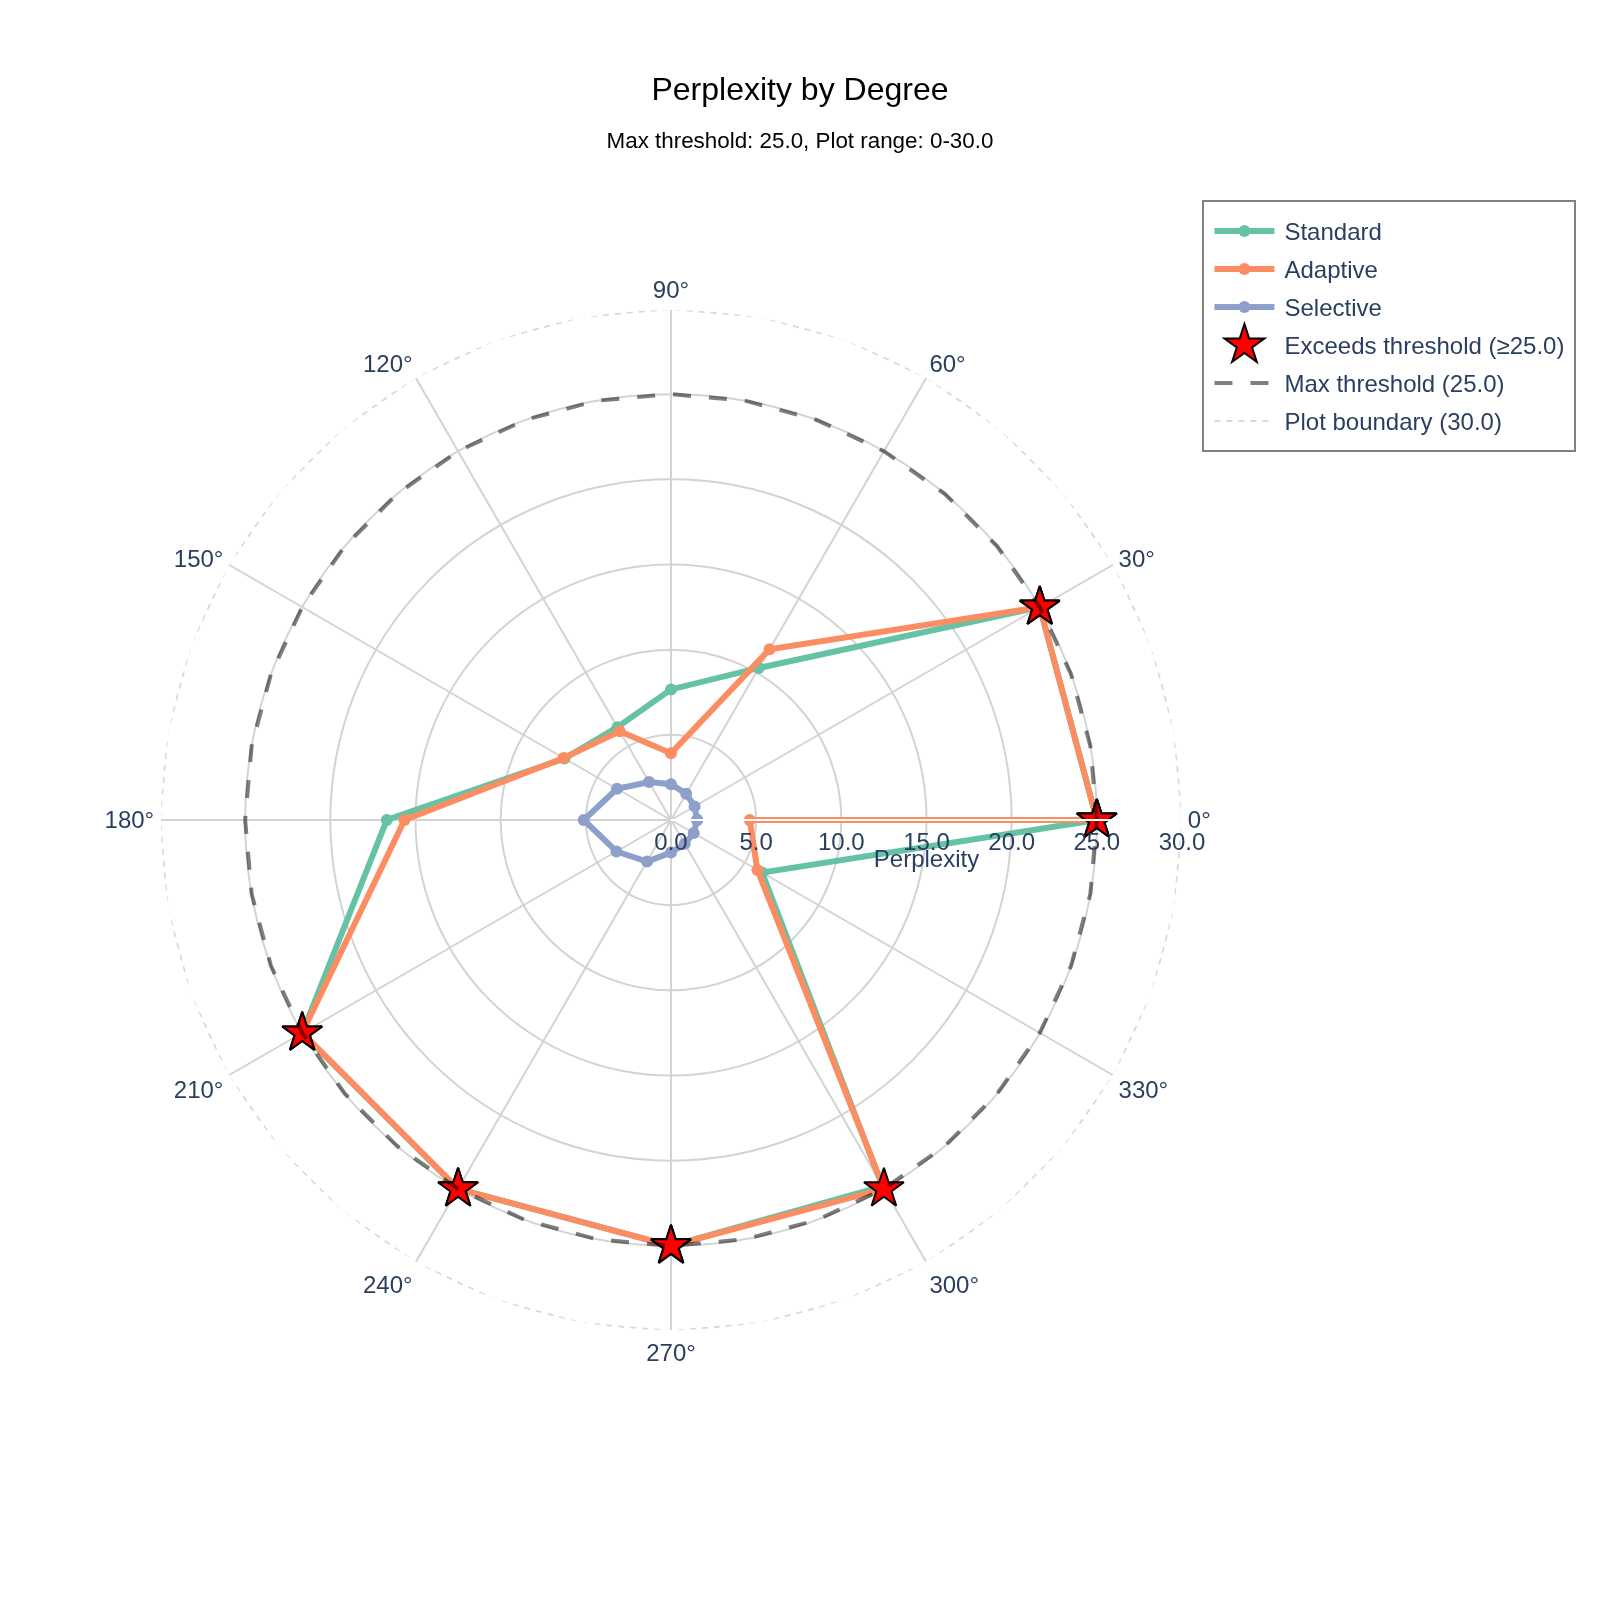

📊 Static image displayed for GitLab compatibility


In [7]:
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import numpy as np
from typing import Dict, List, Tuple
import plotly.colors as pc

def plot_spider_chart_plotly(
    data_dict: Dict[str, List[Tuple[float, float]]],
    max_perplexity: float = 25.0,
    padding_ratio: float = 0.2,
    width: int = 800,
    height: int = 800,
    title: str = None,
    save_static: bool = True,
    static_filename: str = "spider_chart.png"
):
    """
    Plot an interactive spider/radar chart with GitLab compatibility.
    
    Args:
        data_dict: Dictionary mapping evaluation types to lists of (degree, perplexity) tuples
        max_perplexity: Maximum perplexity value to mark with stars
        padding_ratio: Ratio to extend the plot beyond max_perplexity (default 0.2 = 20%)
        width: Figure width in pixels
        height: Figure height in pixels
        title: Custom title for the chart
        save_static: Whether to save static PNG for GitLab viewing
        static_filename: Filename for static image
    """
    # Extract unique degrees from all data series and sort them
    all_degrees = set()
    for points in data_dict.values():
        for degree, _ in points:
            all_degrees.add(degree)
    
    degrees = np.array(sorted(all_degrees))
    
    # Calculate plot range with padding
    plot_max = max_perplexity * (1 + padding_ratio)
    
    # Create figure
    fig = go.Figure()
    
    # Generate automatic colors using Plotly's color palette
    n_series = len(data_dict)
    colors = px.colors.qualitative.Set2[:n_series] if n_series <= len(px.colors.qualitative.Set2) else px.colors.qualitative.Plotly
    
    # Collect all exceed points for a single marker trace
    all_exceed_theta = []
    all_exceed_original = []
    all_exceed_series = []
    
    for idx, (eval_type, points) in enumerate(data_dict.items()):
        # Create a dictionary for quick lookup
        point_dict = {degree: perplexity for degree, perplexity in points}
        
        # Extract perplexities in order of degrees
        perplexities_original = []
        theta_values = []
        for deg in degrees:
            if deg in point_dict:
                perplexities_original.append(point_dict[deg])
                theta_values.append(deg)
        
        perplexities_original = np.array(perplexities_original)
        theta_values = np.array(theta_values)
        
        # Cap perplexities at max_perplexity for plotting
        perplexities_capped = np.minimum(perplexities_original, max_perplexity)
        
        # Sort data by theta for proper line connection
        sort_indices = np.argsort(theta_values)
        theta_sorted = theta_values[sort_indices]
        perplexities_sorted = perplexities_capped[sort_indices]
        perplexities_original_sorted = perplexities_original[sort_indices]
        
        # Close the circle by appending the first point at the end
        theta_closed = np.append(theta_sorted, theta_sorted[0])
        perplexities_closed = np.append(perplexities_sorted, perplexities_sorted[0])
        perplexities_original_closed = np.append(perplexities_original_sorted, perplexities_original_sorted[0])
        
        # Add the main line trace (without fill)
        fig.add_trace(go.Scatterpolar(
            r=perplexities_closed,
            theta=theta_closed,
            mode='lines+markers',
            name=eval_type,
            line=dict(color=colors[idx % len(colors)], width=3),
            marker=dict(size=6, color=colors[idx % len(colors)]),
            hovertemplate=f'<b>{eval_type}</b><br>' +
                         'Degree: %{theta}°<br>' +
                         'Perplexity: %{customdata}<br>' +
                         '<extra></extra>',
            customdata=perplexities_original_closed  # Store original values for hover
        ))
        
        # Collect exceed points for unified marker trace
        exceed_mask = perplexities_original >= max_perplexity
        if np.any(exceed_mask):
            exceed_theta = theta_values[exceed_mask]
            exceed_original = perplexities_original[exceed_mask]
            
            all_exceed_theta.extend(exceed_theta)
            all_exceed_original.extend(exceed_original)
            all_exceed_series.extend([eval_type] * len(exceed_theta))
    
    # Add single marker trace for all exceed points
    if all_exceed_theta:
        fig.add_trace(go.Scatterpolar(
            r=np.full(len(all_exceed_theta), max_perplexity),
            theta=all_exceed_theta,
            mode='markers',
            name=f'Exceeds threshold (≥{max_perplexity})',
            marker=dict(
                symbol='star',
                size=15,
                color='red',
                line=dict(color='black', width=1)
            ),
            showlegend=True,
            hovertemplate='<b>Exceeds threshold</b><br>' +
                         'Series: %{customdata[1]}<br>' +
                         'Degree: %{theta}°<br>' +
                         'Actual Perplexity: %{customdata[0]}<br>' +
                         f'Threshold: {max_perplexity}<br>' +
                         '<extra></extra>',
            customdata=list(zip(all_exceed_original, all_exceed_series))
        ))
    
    # Add reference circle at max_perplexity
    theta_circle = np.linspace(0, 360, 37)  # 37 points to include 0 and 360
    fig.add_trace(go.Scatterpolar(
        r=np.full_like(theta_circle, max_perplexity),
        theta=theta_circle,
        mode='lines',
        name=f'Max threshold ({max_perplexity})',
        line=dict(color='black', width=2, dash='dash'),
        opacity=0.5,
        hovertemplate=f'Threshold: {max_perplexity}<br><extra></extra>'
    ))
    
    # Add outermost circle at plot_max
    fig.add_trace(go.Scatterpolar(
        r=np.full_like(theta_circle, plot_max),
        theta=theta_circle,
        mode='lines',
        name=f'Plot boundary ({plot_max:.1f})',
        line=dict(color='gray', width=1, dash='dot'),
        opacity=0.3,
        hovertemplate=f'Plot boundary: {plot_max:.1f}<br><extra></extra>'
    ))
    
    # Create custom radial tick values
    radial_ticks = np.linspace(0, plot_max, 7)
    radial_ticks = np.sort(np.append(radial_ticks, max_perplexity))
    radial_ticks = np.unique(radial_ticks)
    
    # Prepare degree labels (prioritize 0 over 360 if both exist)
    display_degrees = degrees.copy()
    if 0 in degrees and 360 in degrees:
        display_degrees = degrees[degrees != 360]  # Remove 360, keep 0
    
    # Update layout
    if title is None:
        title = f'Perplexity by Degree<br><sub>Max threshold: {max_perplexity}, Plot range: 0-{plot_max:.1f}</sub>'
    
    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, plot_max],
                tickvals=radial_ticks,
                ticktext=[f'{tick:.1f}' for tick in radial_ticks],
                title=dict(text='Perplexity', font=dict(size=12)),
                gridcolor='lightgray',
                gridwidth=1,
            ),
            angularaxis=dict(
                tickvals=display_degrees,
                ticktext=[f'{int(d)}°' for d in display_degrees],
                direction='counterclockwise',  # Change to counterclockwise (right to left)
                rotation=0,  # Start from top
                gridcolor='lightgray',
                gridwidth=1,
            ),
            bgcolor='white'
        ),
        title=dict(
            text=title,
            x=0.5,
            font=dict(size=16, color='black'),
            pad=dict(t=20)
        ),
        showlegend=True,
        legend=dict(
            orientation="v",
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.02,
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='gray',
            borderwidth=1
        ),
        width=width,
        height=height,
        paper_bgcolor='white',
        plot_bgcolor='white'
    )
    
    # GitLab Compatibility: Save static image
    if save_static:
        try:
            fig.write_image(static_filename, width=width, height=height, scale=2)
            print(f"✅ Static image saved as {static_filename}")
            
            # Display static image in Jupyter
            try:
                from IPython.display import Image, display
                display(Image(static_filename))
                print("📊 Static image displayed for GitLab compatibility")
            except ImportError:
                print("ℹ️ IPython not available, static image saved but not displayed")
                
        except Exception as e:
            print(f"⚠️ Could not save static image: {e}")
            print("💡 Install kaleido: pip install kaleido")
    
    return fig



# Create the plot
fig = plot_spider_chart_plotly(
    data_dict,
    max_perplexity=25.0,
    padding_ratio=0.2,
    width=800,
    height=800,
    save_static=True,
    static_filename="qwen2.5-3b-instruct.png"
)

# Show the plot
# fig.show()

# Optionally save as HTML
# fig.write_html("qwen2.5-3b-instruct.html")

##################################################
# Display the static image in notebook
# from IPython.display import Image, display
# display(Image("qwen2.5-3b-instruct.png"))

✅ Static image saved as llama-3.2-3b-instruct.png


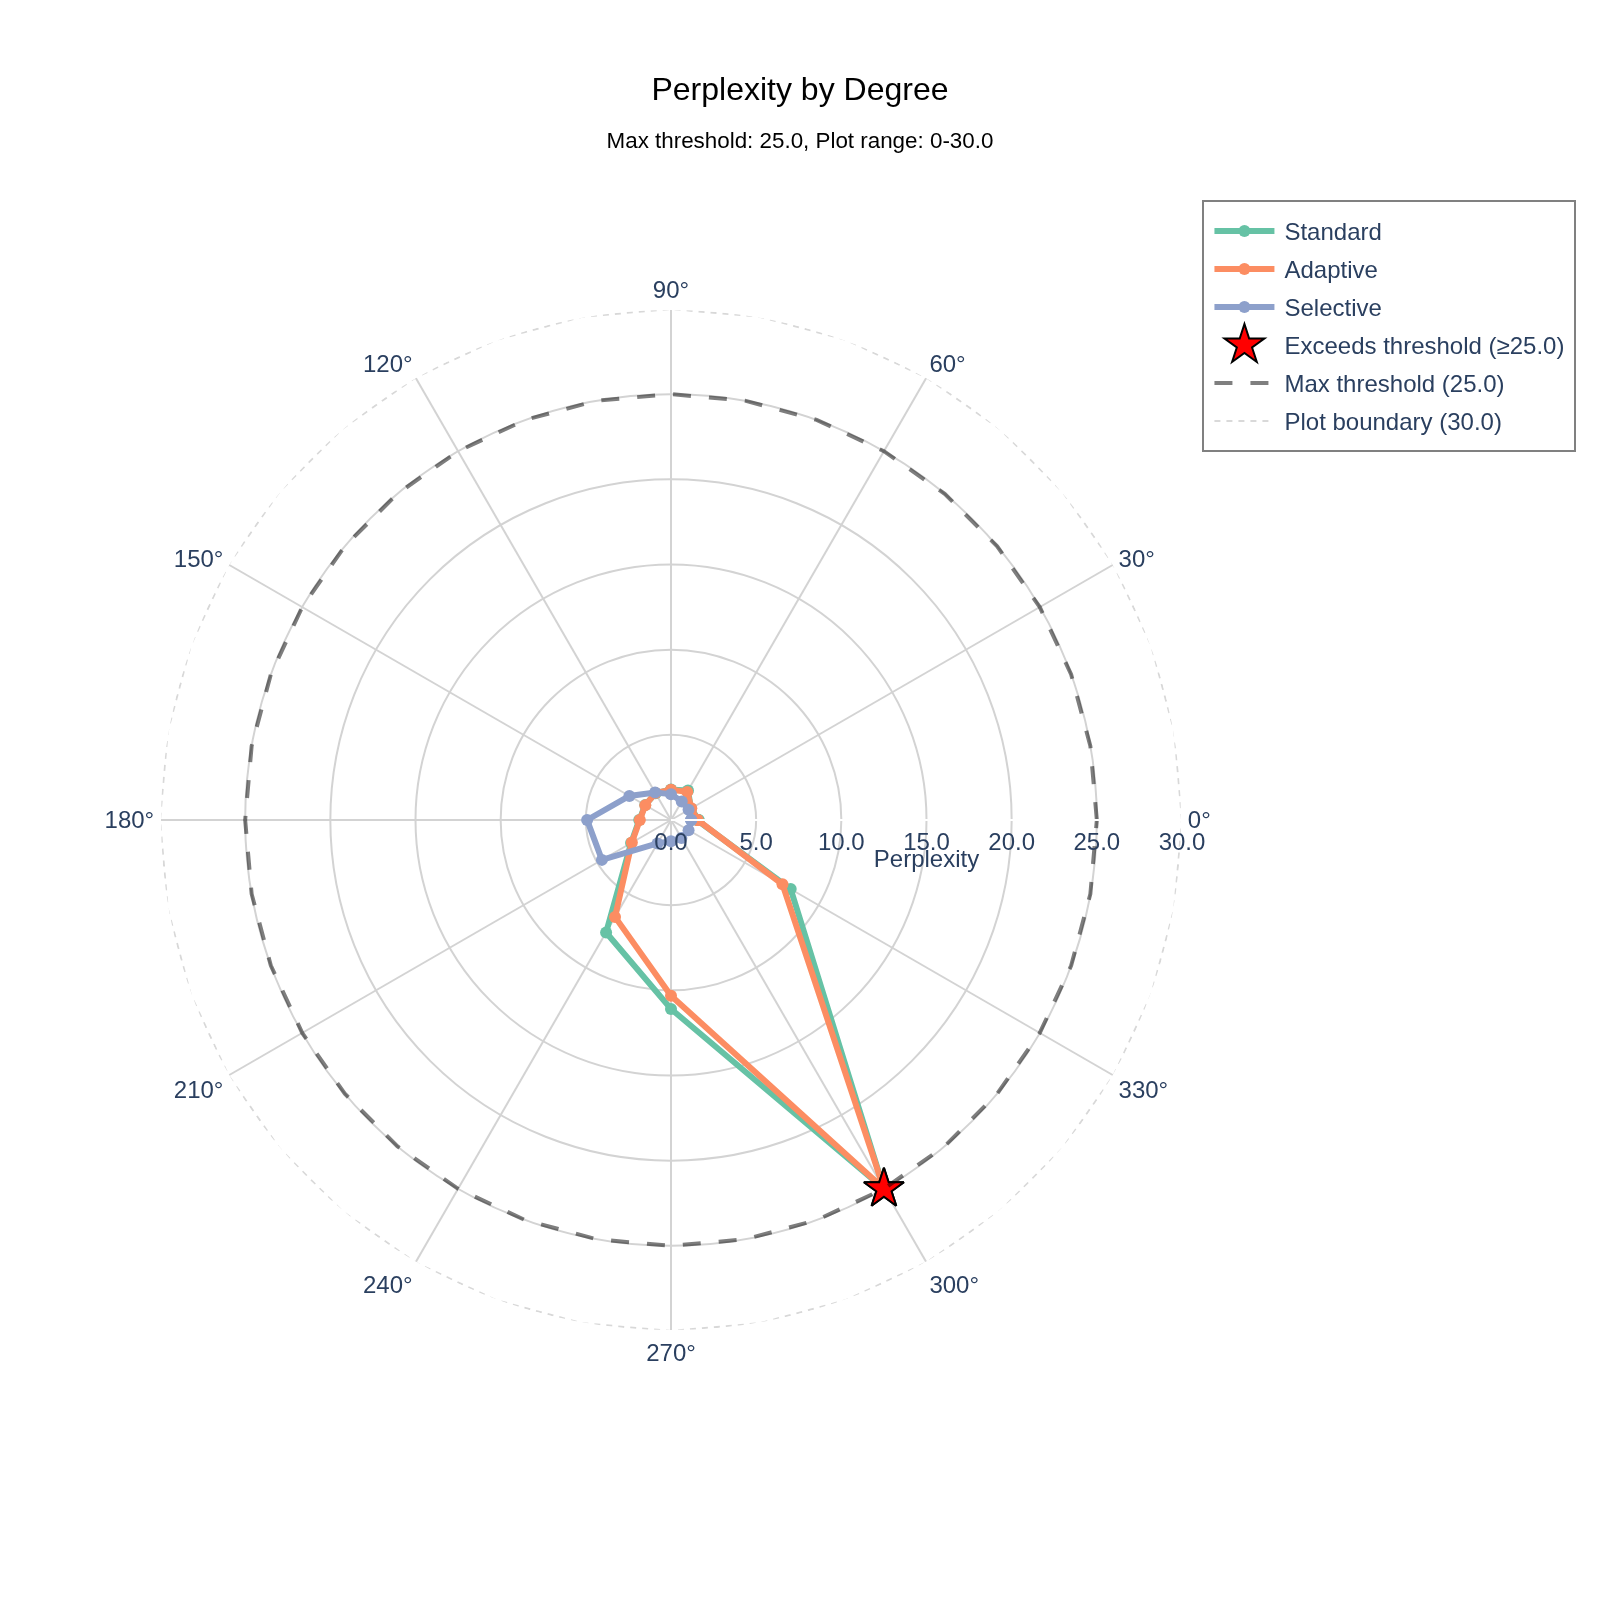

📊 Static image displayed for GitLab compatibility


In [8]:
# Create the plot
fig = plot_spider_chart_plotly(
    llama_3_2_3b_dict,
    max_perplexity=25.0,
    padding_ratio=0.2,
    width=800,
    height=800,
    save_static=True,
    static_filename="llama-3.2-3b-instruct.png"
)

# Show the plot
# fig.show()

# Optionally save as HTML
# fig.write_html("llama-3.2-3b-instruct.html")


# Display the static image in notebook
# from IPython.display import Image, display
# display(Image("llama-3.2-3b-instruct.png"))